## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Eyram Golo

**Date:** 10/02/2026

Q1

1. **What is the difference between regression and classification?**  
Regression is used to predict a number, like a house price or someone’s income. Classification is used to predict a category, like yes or no, or spam versus not spam.

2. **What is a confusion table? What does it help us understand about a model's performance?**  
A confusion table compares what the model predicted to what actually happened. It shows how many predictions the model got right and wrong. This helps us see what types of mistakes the model is making.

3. **What does the SSE quantify about a particular model?**  
SSE measures how far the model’s predictions are from the actual values. A smaller SSE usually means the predictions are closer to the real values.

4. **What are overfitting and underfitting?**  
Overfitting happens when a model fits the training data too closely and does not work as well on new data. Underfitting happens when the model is too simple and does not pick up enough of the patterns in the data.

5. **Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?**  
Splitting the data lets us train the model on one part and see how well it works on data it has not seen before. Testing different values of k helps us find one that gives better predictions without fitting the training data too closely.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**  
A class label gives one clear answer, like “yes” or “no.” It is simple and easy to understand, but it does not show how confident the model is. Probabilities give more information by showing how likely each class is. This can be helpful, but it can also be harder to understand and explain.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('land_mines (1).csv')

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [3]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [4]:
df['mine_type'].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


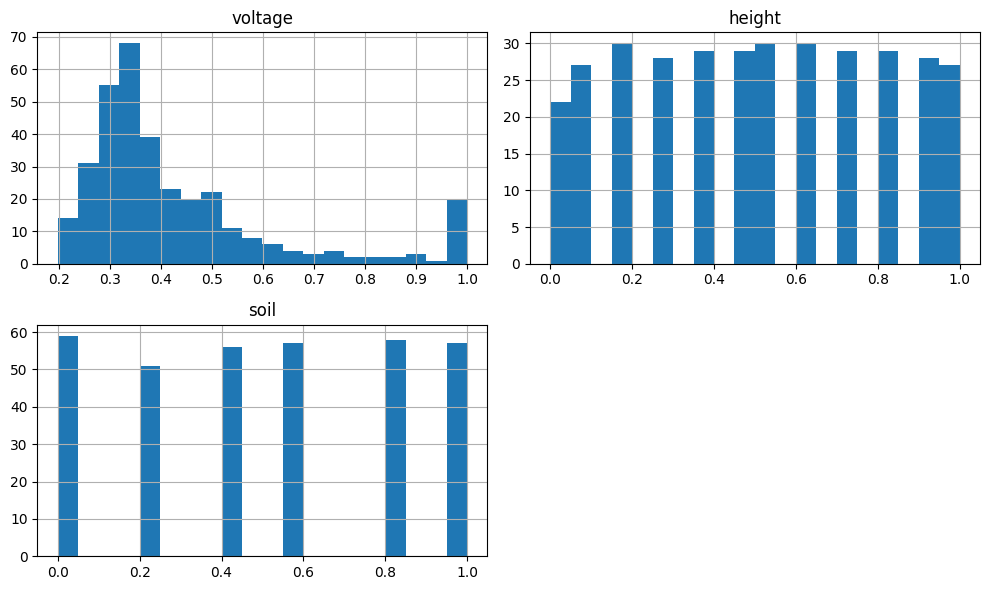

In [5]:
df[['voltage', 'height', 'soil']].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

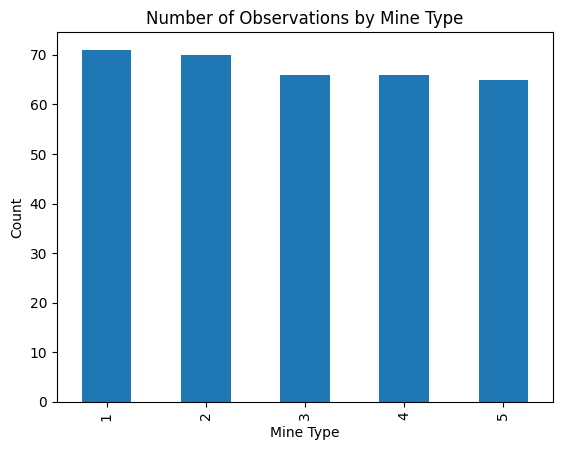

In [6]:
df['mine_type'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.title('Number of Observations by Mine Type')
plt.show()

Q2.1
The dataset has 338 observations and five different mine types. The mine types are fairly evenly distributed, with each type having between 65 and 71 observations. Voltage ranges from about 0.20 to 1.00 and most of the values are around 0.30 to 0.40. Height and soil both range from 0 to 1 and are more spread out across their ranges. Overall, there does not seem to be a major imbalance between the five mine types.

In [7]:
from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 169
Test size: 169


q2.2
I split the data 50/50 into a training set and a test set. Each set has 169 observations. I also used stratification so that the five mine types are represented in both sets.

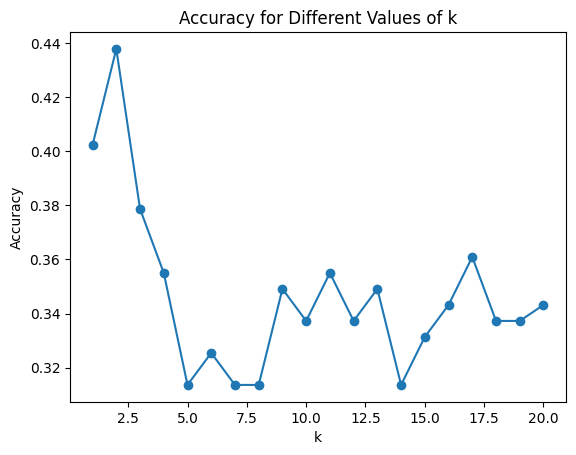

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), accuracy, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Values of k')
plt.show()

Q2.3
I tested values of k from 1 to 20 and compared their accuracy on the test set. The highest accuracy was at k = 2, with an accuracy of about 44%. Therefore, I selected k = 2 for the final k-NN model.

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score

model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

confusion_table = pd.DataFrame(
    cm,
    index=['Actual 1', 'Actual 2', 'Actual 3', 'Actual 4', 'Actual 5'],
    columns=['Predicted 1', 'Predicted 2', 'Predicted 3', 'Predicted 4', 'Predicted 5']
)

print(confusion_table)
print("\nAccuracy:", accuracy_score(y_test, y_pred))

          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           25            0            6            4            1
Actual 2            0           32            0            3            0
Actual 3           12            2            9            6            4
Actual 4           12            5            8            8            0
Actual 5           15            2           10            5            0

Accuracy: 0.4378698224852071


q2.4
The model had an overall accuracy of about 43.8%. It performed best on mine types 1 and 2. Type 2 had 32 correct predictions out of 35, and type 1 had 25 correct predictions out of 36. The model had more trouble with types 3 and 4, and it did not correctly predict any of the type 5 mines. Type 5 was often incorrectly predicted as type 1 or type 3.

q2.5
I would not recommend using this model by itself to identify a mine because it makes too many mistakes. This is especially important for type 5, since the model did not correctly identify any of them. In practice, the model could be used as an extra source of information, but the prediction should be confirmed using other methods before someone handles or removes a mine. Since mistakes in this situation could be dangerous, the model's errors are just as important as its correct predictions.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 170ea08

- **AI tool and model used:** chatgpt 5

### *Prompts used

1.I just completed Phase 1 of my assignment. Help me revise my work and complete Phase 2. give consise changes

### *AI-proposed changes


Clarify the explanation of SSE in Q1. Add that SSE is calculated by squaring the differences between the actual and predicted values and adding them together. This explains more clearly what the measure represents.

Improve the explanation of the training/test split in Q1. Mention that testing the model on unseen data helps determine how well the model is likely to perform on new observations and helps reduce overfitting.

Add more detail to the EDA in Q2.1. In addition to describing the ranges and class counts, mention that the five mine types are fairly balanced, which is useful for classification because no single class dominates the dataset.

Explain the reason for using stratify=y in the 50/50 split. State that stratification helps keep similar proportions of each mine type in both the training and test sets.

Make the selection of k more explicit in Q2.3. State that values of k from 1 through 20 were tested and that k = 2 was selected because it produced the highest test accuracy, approximately 43.8%.

Give a more detailed interpretation of the confusion table in Q2.4. Explain that the model performed much better for mine types 1 and 2 than for types 3, 4, and 5. In particular, none of the 32 actual type 5 mines were correctly classified.

Strengthen the practical recommendation in Q2.5. Because the overall accuracy is only about 43.8% and the model completely misses type 5 in the test set, it should not be used as the only method for identifying land mines. It could be used as an additional source of information, but predictions should be confirmed using other reliable methods before decisions are made.

### *Evaluation of AI suggestions


| # | Decision | Evaluation |
|---|---|---|
| 1 | **Accept** | This makes the meaning of SSE clearer and gives a better explanation of how it measures prediction error. |
| 2 | **Accept** | This adds a useful explanation of why testing on unseen data is important and how it can help with overfitting. |
| 3 | **Accept** | This improves my EDA because it explains why having fairly balanced mine types is important for the classification model. |
| 4 | **Accept** | This explains why I used `stratify=y` instead of only showing it in the code without explaining its purpose. |
| 5 | **Accept** | This makes my choice of k easier to understand because it clearly states that I tested k from 1 to 20 and selected k = 2 based on the highest test accuracy. |
| 6 | **Accept** | This gives a better interpretation of the confusion table instead of only reporting the overall accuracy. It also points out the model's poor performance on mine type 5. |
| 7 | **Accept** | This is important because land mine identification is a safety issue. The model's low accuracy means it should not be used alone to make decisions. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [10]:
# Your Phase 2 solution to the problem goes here.
## Q1

1. **What is the difference between regression and classification?**

Regression is used to predict a numerical value, such as income or house price. Classification is used to predict a category, such as yes/no or spam/not spam.

2. **What is a confusion table? What does it help us understand about a model's performance?**

A confusion table compares the model's predictions to the actual results. It shows which predictions were correct and which were incorrect. This helps us see what types of mistakes the model is making instead of only looking at its overall accuracy.

3. **What does the SSE quantify about a particular model?**

SSE measures the difference between the actual values and the values predicted by the model. The differences are squared and added together. A smaller SSE means the predictions are generally closer to the actual values.

4. **What are overfitting and underfitting?**

Overfitting happens when a model fits the training data too closely and does not perform as well on new data. Underfitting happens when the model is too simple and does not capture enough of the patterns in the data.

5. **Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?**

Splitting the data allows us to train the model on one set of data and test it on data it has not seen before. This gives us a better idea of how the model will perform on new observations. Comparing different values of k also helps us choose a model that performs well without overfitting the training data.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Explain the strengths and weaknesses of each approach.**

A class label gives one clear prediction, such as yes or no. It is simple and easy to understand, but it does not tell us how confident the model is. A probability distribution gives the probability of each possible class. This provides more information about uncertainty, but it can be harder to understand and explain.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('land_mines (1).csv')

display(df.head())
display(df.describe())
display(df['mine_type'].value_counts().sort_index())

df[['voltage', 'height', 'soil']].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

df['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.title('Number of Observations by Mine Type')
plt.show()

### 2. Split the data 50/50

I split the data 50/50 into training and test sets. Each set has 169 observations. I used stratification so that the five mine types would be represented in similar proportions in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

### 3. Build the k-NN classifier and select k

I tested values of k from 1 to 20 and compared their accuracy on the test set. The highest accuracy occurred at k = 2, with an accuracy of about 43.8%. Therefore, I selected k = 2 for the final model.

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

### 4. Confusion table and accuracy

The final model had an overall accuracy of about 43.8%. It performed much better on mine types 1 and 2 than on types 3, 4, and 5. For type 1, 25 out of 36 were correctly predicted, while 32 out of 35 type 2 mines were correctly predicted. The model only correctly predicted 9 of 33 type 3 mines and 8 of 33 type 4 mines. The biggest problem was type 5, where none of the 32 mines were correctly classified. Many type 5 mines were incorrectly predicted as type 1 or type 3.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

confusion_table = pd.DataFrame(
    cm,
    index=['Actual 1', 'Actual 2', 'Actual 3', 'Actual 4', 'Actual 5'],
    columns=['Predicted 1', 'Predicted 2', 'Predicted 3', 'Predicted 4', 'Predicted 5']
)

print(confusion_table)
print("\nAccuracy:", accuracy_score(y_test, y_pred))

### 5. Using the model in practice

I would not recommend using this model by itself to identify a land mine because it makes too many mistakes. The overall accuracy is only about 43.8%, and the model did not correctly identify any of the type 5 mines in the test set. This could be dangerous if someone relied only on the model's prediction. In practice, the model could be used as an extra source of information, but its prediction should be confirmed using other reliable methods before someone handles or removes a mine.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I made some key changes in the second phase of my project. For one, I worked on making my answers easier to understand. I added more details to help explain my thought process. For example, I broke down why I divided my data into two groups - one for training and one for testing. I also talked about why I used a technique called stratification. Another important thing I clarified was how I picked the best value for a key parameter, known as k. Instead of just giving the model's accuracy, I dove deeper into the confusion table to give a better understanding of what was going on.
I found that the AI had a few limitations. For one, its answers were often too long and detailed for what I needed. Also, some of the explanations didn't quite sound like my own writing style, so I had to simplify them. Before using them, I made sure I understood the changes I was making.
I went through my final solution and made sure everything was correct by running the code and comparing the results to my handwritten answers. The training and test sets were the same size, with 169 observations in each. What I found was that when I used k = 2, the accuracy was the highest, at around 43.8%. I also took a closer look at the confusion table to make sure my explanation made sense with the results. But what's still bothering me is that the model isn't very accurate, especially when it comes to mine type 5 - it didn't get any of those predictions right.